# Notebook para fazer um stratified split dos dados

- A maior parte do código está comentado para não criar mais pastas ou adicionar mais imagens, visto que já está tudo criado

In [1]:
#Imports

import numpy as np
import keras
from keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt

import os
import shutil
from sklearn.model_selection import train_test_split

from EDA_utils import (build_filepaths_dict, images_per_class)

In [ ]:
#Ir buscar os paths de cada imagem
Image_paths =[]
for root, dirs, files in os.walk("wikiart_datasets"):
    for file in files:
        path = os.path.join(root,file)
        Image_paths.append(path)

In [ ]:
#Ir buscar os labels de cada imagem
labels= []
for root, dirs, files in os.walk("wikiart_datasets"):
    for file in files:
        labels.append(root[17:])

In [4]:
#Dar split em train e test
X_train, X_test,  y_train, y_test = train_test_split(Image_paths,labels, test_size=0.3, train_size=0.7, stratify=labels)

In [5]:
#Dar split do test e val e test
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, train_size=0.5, stratify=y_test)

In [ ]:
print(len(X_val),
      len(X_test),
      len(X_train))
# Cada split tem o tamanho que queremos

1999 2000 9329


In [7]:
#Criar pasta data
os.makedirs("/home/andre/Wikiart_Project/Data")

In [8]:
#Criar pasta Train
os.makedirs("/home/andre/Wikiart_Project/Data/Train")

In [9]:
#Criar pasta Validation
os.makedirs("/home/andre/Wikiart_Project/Data/Validation")

In [10]:
#Criar pasta Test
os.makedirs("/home/andre/Wikiart_Project/Data/Test")

In [11]:
#Getting the unique labels
authors = set(labels)

In [12]:
#Confirm if they are 23
len(authors)

23

In [ ]:
#Add the folders of the authors for Train
for author in authors:
    if not os.path.exists(f"/home/andre/Wikiart_Project/Data/Train/{author}"):
        os.makedirs(f"/home/andre/Wikiart_Project/Data/Train/{author}")

In [ ]:
#Add the folders of the authors for Test
for author in authors:
    if not os.path.exists(f"/home/andre/Wikiart_Project/Data/Test/{author}"):
        os.makedirs(f"/home/andre/Wikiart_Project/Data/Test/{author}")

In [ ]:
#Add the folders of the authors for Validation
for author in authors:
    if not os.path.exists(f"/home/andre/Wikiart_Project/Data/Validation/{author}"):
        os.makedirs(f"/home/andre/Wikiart_Project/Data/Validation/{author}")

In [ ]:
#Copiar os ficheiros para a pasta train
for path in X_train:
    painter = path.split("/")[-2]
    shutil.copy(path, f"Data/Train/{painter}") 

In [ ]:
#Copiar os ficheiros para a pasta test
for path in X_test:
    painter = path.split("/")[-2]
    shutil.copy(path, f"Data/Test/{painter}") 

In [ ]:
#Copiar os ficheiros para a pasta Validation
for path in X_val:
    painter = path.split("/")[-2]
    shutil.copy(path, f"Data/Validation/{painter}") 

## Test if the Stratified split was done rigth

In [13]:
data2 = image_dataset_from_directory(
    'wikiart_datasets',
    label_mode= "categorical",
    batch_size= 64,
    image_size= (512,512),
    interpolation= "bilinear",
    verbose= False)

### Train Data set

In [7]:
Train_df = image_dataset_from_directory(
    "Data/Train",
    label_mode= "categorical",
    batch_size= 64,
    image_size= (512,512),
    interpolation= "bilinear",
)

Found 9329 files belonging to 23 classes.


Author Albrecht_Durer has 406 paintings
Author Boris_Kustodiev has 311 paintings
Author Camille_Pissarro has 432 paintings
Author Childe_Hassam has 267 paintings
Author Claude_Monet has 654 paintings
Author Edgar_Degas has 300 paintings
Author Eugene_Boudin has 272 paintings
Author Gustave_Dore has 369 paintings
Author Ilya_Repin has 265 paintings
Author Ivan_Aivazovsky has 283 paintings
Author Ivan_Shishkin has 255 paintings
Author John_Singer_Sargent has 384 paintings
Author Marc_Chagall has 375 paintings
Author Martiros_Saryan has 282 paintings
Author Nicholas_Roerich has 890 paintings
Author Pablo_Picasso has 374 paintings
Author Paul_Cezanne has 284 paintings
Author Pierre_Auguste_Renoir has 681 paintings
Author Pyotr_Konchalovsky has 451 paintings
Author Raphael_Kirchner has 253 paintings
Author Rembrandt has 381 paintings
Author Salvador_Dali has 235 paintings
Author Vincent_van_Gogh has 925 paintings

Max: 925 paintings by Vincent_van_Gogh
Min: 235 paintings by Salvador_Dali


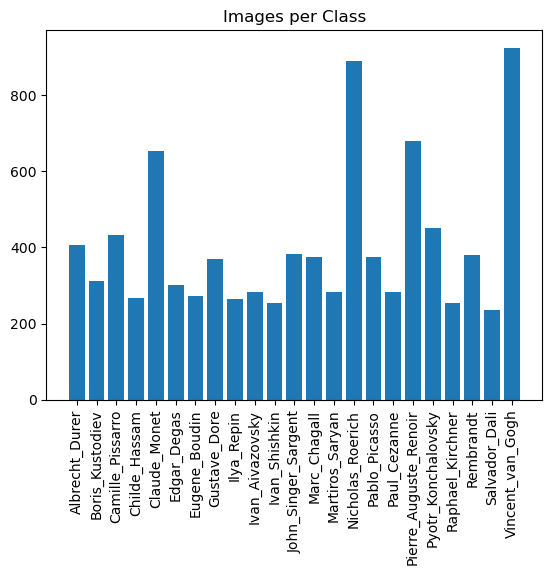

In [9]:
authors_painting_filepaths_train = build_filepaths_dict(data2.class_names, 'Data/Train')
count = images_per_class(authors_painting_filepaths_train)

### Validation Data set

In [24]:
Val_df = image_dataset_from_directory(
    "Data/Validation",
    label_mode= "categorical",
    batch_size= 64,
    image_size= (512,512),
    interpolation= "bilinear"
)

Found 1999 files belonging to 23 classes.


Author Albrecht_Durer has 87 paintings
Author Boris_Kustodiev has 66 paintings
Author Camille_Pissarro has 93 paintings
Author Childe_Hassam has 58 paintings
Author Claude_Monet has 140 paintings
Author Edgar_Degas has 64 paintings
Author Eugene_Boudin has 59 paintings
Author Gustave_Dore has 79 paintings
Author Ilya_Repin has 57 paintings
Author Ivan_Aivazovsky has 61 paintings
Author Ivan_Shishkin has 55 paintings
Author John_Singer_Sargent has 82 paintings
Author Marc_Chagall has 80 paintings
Author Martiros_Saryan has 60 paintings
Author Nicholas_Roerich has 190 paintings
Author Pablo_Picasso has 80 paintings
Author Paul_Cezanne has 61 paintings
Author Pierre_Auguste_Renoir has 146 paintings
Author Pyotr_Konchalovsky has 96 paintings
Author Raphael_Kirchner has 55 paintings
Author Rembrandt has 81 paintings
Author Salvador_Dali has 51 paintings
Author Vincent_van_Gogh has 198 paintings

Max: 198 paintings by Vincent_van_Gogh
Min: 51 paintings by Salvador_Dali


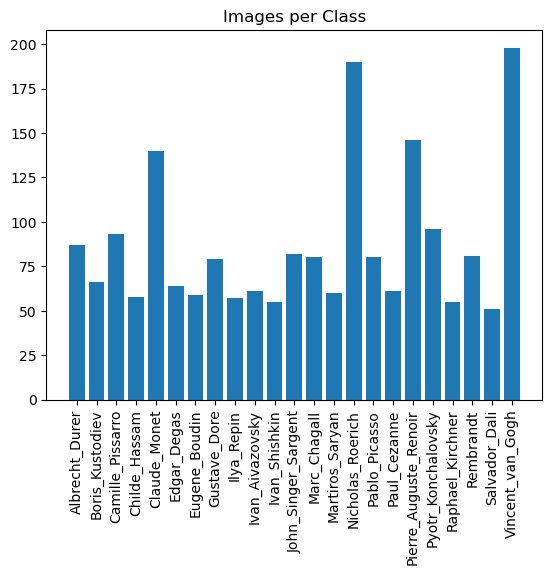

In [11]:
authors_painting_filepaths_val = build_filepaths_dict(data2.class_names, 'Data/Validation')
count = images_per_class(authors_painting_filepaths_val)

### Test Data Set

In [28]:
Test_df = image_dataset_from_directory(
    "Data/Test",
    label_mode= "categorical",
    batch_size= 64,
    image_size= (512,512),
    interpolation= "bilinear")

Found 2000 files belonging to 23 classes.


Author Albrecht_Durer has 87 paintings
Author Boris_Kustodiev has 67 paintings
Author Camille_Pissarro has 93 paintings
Author Childe_Hassam has 57 paintings
Author Claude_Monet has 140 paintings
Author Edgar_Degas has 64 paintings
Author Eugene_Boudin has 58 paintings
Author Gustave_Dore has 80 paintings
Author Ilya_Repin has 56 paintings
Author Ivan_Aivazovsky has 60 paintings
Author Ivan_Shishkin has 54 paintings
Author John_Singer_Sargent has 83 paintings
Author Marc_Chagall has 81 paintings
Author Martiros_Saryan has 61 paintings
Author Nicholas_Roerich has 191 paintings
Author Pablo_Picasso has 80 paintings
Author Paul_Cezanne has 61 paintings
Author Pierre_Auguste_Renoir has 146 paintings
Author Pyotr_Konchalovsky has 97 paintings
Author Raphael_Kirchner has 54 paintings
Author Rembrandt has 82 paintings
Author Salvador_Dali has 50 paintings
Author Vincent_van_Gogh has 198 paintings

Max: 198 paintings by Vincent_van_Gogh
Min: 50 paintings by Salvador_Dali


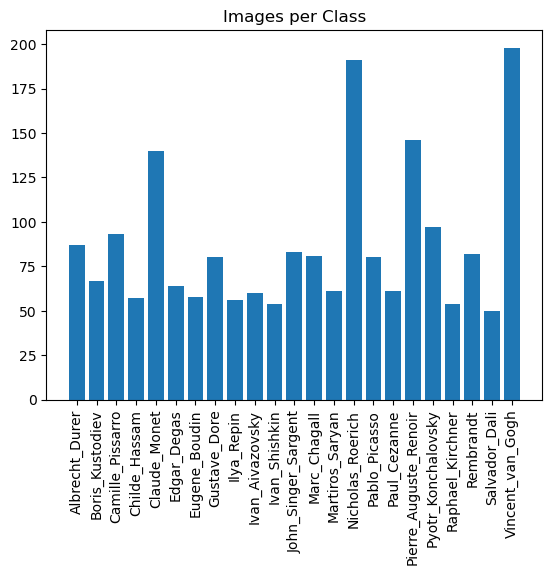

In [12]:
authors_painting_filepaths_test = build_filepaths_dict(data2.class_names, 'Data/Test')
count = images_per_class(authors_painting_filepaths_test)

As we can see in the 3 Graphs plotted above, they are equal so the distribution of classes in the 3 datasets is the same, therefore we can conclude that the stratified sampling splits was well done.